# 📈 Baseline 1 RD-Curve — LOL eval15

**목적:** 순정 CompressAI(`bmshj2018_hyperprior`)를 quality 1·2·3으로 eval15(야간 low 15장)에 돌려
**BPP(용량) ↔ PSNR·SSIM(화질)** 의 Rate-Distortion 곡선을 그린다. (연구계획서 5주차 대조군 비교의 기준선)

**RD-Curve 읽는 법:** quality를 올리면 → 용량(BPP)↑ → 화질(PSNR/SSIM)↑. 우상향이 정상.
점 하나로는 곡선이 안 되므로 **quality 3개를 찍어 이어** 곡선을 만든다.

> ✅ 로컬 실측 참고값 (eval15 low 15장 평균):
> | q | BPP | PSNR | SSIM |
> |:-:|:-:|:-:|:-:|
> | 1 | 0.0348 | 35.59 dB | 0.9426 |
> | 2 | 0.0467 | 36.73 dB | 0.9533 |
> | 3 | 0.0638 | 37.87 dB | 0.9632 |


### 0. 드라이브 마운트 + 설치
⚠️ 설치 후 **[런타임 → 세션 다시 시작]** 하고, 이 셀은 건너뛰고 아래부터 실행하세요.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 버전 충돌 방지를 위해 고정 (Baseline과 동일)
!pip install compressai "numpy==1.26.4" "scipy==1.13.1"
!pip install pytorch-msssim   # 정확한 SSIM용 (선택)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 75.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 22.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.5/444.5 kB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.2/314.2 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
     

### 1. 임포트 & 설정
- `DATASET_ROOT`, `SPLIT`만 본인 환경에 맞게 확인하세요.
- `SPLIT='low'` = 야간 노이즈 이미지를 압축 대상으로 사용 (Baseline 1의 "야간 뭉개짐" 증명 목적).

In [1]:
import os, glob, math, json
import torch
import numpy as np
from PIL import Image
import torchvision.transforms.functional as TF
from compressai.zoo import bmshj2018_hyperprior
import matplotlib.pyplot as plt

# --- 설정 ---
DATASET_ROOT = '/content/drive/MyDrive/CUAI_summer_conference/LOL_Dataset/lol_dataset/eval15'
SPLIT = 'low'                 # 'low'(야간, 권장) 또는 'high'
QUALITIES = [1, 2, 3]         # RD 곡선 점들
SAVE_DIR = '/content/drive/MyDrive/CUAI_summer_conference'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
img_dir = os.path.join(DATASET_ROOT, SPLIT)
paths = sorted(glob.glob(os.path.join(img_dir, '*.png')))
print(f"device={device} | 평가 이미지 {len(paths)}장 ({SPLIT})")

device=cuda | 평가 이미지 15장 (low)


### 2. 유틸 함수 (이미지 로드 / PSNR / SSIM)
- bmshj2018은 입력 H·W가 **64의 배수**여야 안전 → 64 단위로 center-crop.
- SSIM은 `pytorch-msssim`이 있으면 정확한 sliding-window SSIM, 없으면 간이 global SSIM 사용.

In [2]:
def load_img(p):
    img = Image.open(p).convert('RGB')
    w, h = img.size
    W, H = (w // 64) * 64, (h // 64) * 64          # 64 배수로 맞춤
    left, top = (w - W) // 2, (h - H) // 2
    img = img.crop((left, top, left + W, top + H))
    return TF.to_tensor(img).unsqueeze(0)          # 1,3,H,W

def psnr(a, b):
    mse = torch.mean((a - b) ** 2).item()
    return 100.0 if mse == 0 else 10 * math.log10(1.0 / mse)

# SSIM: pytorch-msssim 있으면 정확 버전, 없으면 간이 버전
try:
    from pytorch_msssim import ssim as _ssim_fn
    def ssim(a, b):
        return _ssim_fn(a, b, data_range=1.0).item()
    print("✅ pytorch-msssim 사용 (정확한 SSIM)")
except Exception:
    def ssim(a, b, C1=0.01**2, C2=0.03**2):
        a = 0.299*a[:,0]+0.587*a[:,1]+0.114*a[:,2]
        b = 0.299*b[:,0]+0.587*b[:,1]+0.114*b[:,2]
        mu_a, mu_b = a.mean(), b.mean()
        va, vb = a.var(), b.var()
        cov = ((a-mu_a)*(b-mu_b)).mean()
        return (((2*mu_a*mu_b+C1)*(2*cov+C2))/((mu_a**2+mu_b**2+C1)*(va+vb+C2))).item()
    print("⚠️ 간이 global SSIM 사용 (pytorch-msssim 미설치)")

✅ pytorch-msssim 사용 (정확한 SSIM)


### 3. 평가 — 각 quality로 실제 압축/복원 후 BPP·PSNR·SSIM 측정
`model.compress()`로 **실제 비트스트림**을 만들어 BPP를 잰다 (추정 bpp 아님).
GPU면 15장 × 3 quality가 수십 초 내로 끝난다.

In [3]:
results = {}
for q in QUALITIES:
    print(f"[quality={q}] 로드 중...")
    model = bmshj2018_hyperprior(quality=q, pretrained=True).to(device).eval()
    model.update()                                  # 엔트로피 코딩 테이블 준비

    bpps, psnrs, ssims = [], [], []
    for p in paths:
        x = load_img(p).to(device)
        _, _, H, W = x.shape
        num_pixels = H * W
        with torch.no_grad():
            out = model.compress(x)
            x_hat = model.decompress(out['strings'], out['shape'])['x_hat'].clamp(0, 1)
        total_bits = sum(len(s[0]) for s in out['strings']) * 8
        bpps.append(total_bits / num_pixels)
        psnrs.append(psnr(x_hat, x))
        ssims.append(ssim(x_hat, x))

    results[q] = {'bpp': float(np.mean(bpps)),
                  'psnr': float(np.mean(psnrs)),
                  'ssim': float(np.mean(ssims))}
    print(f"  BPP={results[q]['bpp']:.4f} | PSNR={results[q]['psnr']:.2f}dB | SSIM={results[q]['ssim']:.4f}")

# 결과 저장
os.makedirs(SAVE_DIR, exist_ok=True)
with open(os.path.join(SAVE_DIR, 'rd_results.json'), 'w') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print("💾 rd_results.json 저장 완료")

[quality=1] 로드 중...
Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-hyperprior-1-7eb97409.pth.tar" to /root/.cache/torch/hub/checkpoints/bmshj2018-hyperprior-1-7eb97409.pth.tar


100%|██████████| 20.2M/20.2M [00:00<00:00, 38.3MB/s]


  BPP=0.0348 | PSNR=35.59dB | SSIM=0.8329
[quality=2] 로드 중...
Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-hyperprior-2-93677231.pth.tar" to /root/.cache/torch/hub/checkpoints/bmshj2018-hyperprior-2-93677231.pth.tar


100%|██████████| 20.2M/20.2M [00:00<00:00, 55.8MB/s]


  BPP=0.0467 | PSNR=36.73dB | SSIM=0.8508
[quality=3] 로드 중...
Downloading: "https://compressai.s3.amazonaws.com/models/v1/bmshj2018-hyperprior-3-6d87be32.pth.tar" to /root/.cache/torch/hub/checkpoints/bmshj2018-hyperprior-3-6d87be32.pth.tar


100%|██████████| 20.2M/20.2M [00:00<00:00, 50.7MB/s]


  BPP=0.0638 | PSNR=37.87dB | SSIM=0.8796
💾 rd_results.json 저장 완료


### 4. 그래프 — BPP vs PSNR / BPP vs SSIM
결과 표와 곡선을 함께 출력하고 PNG로 저장한다.

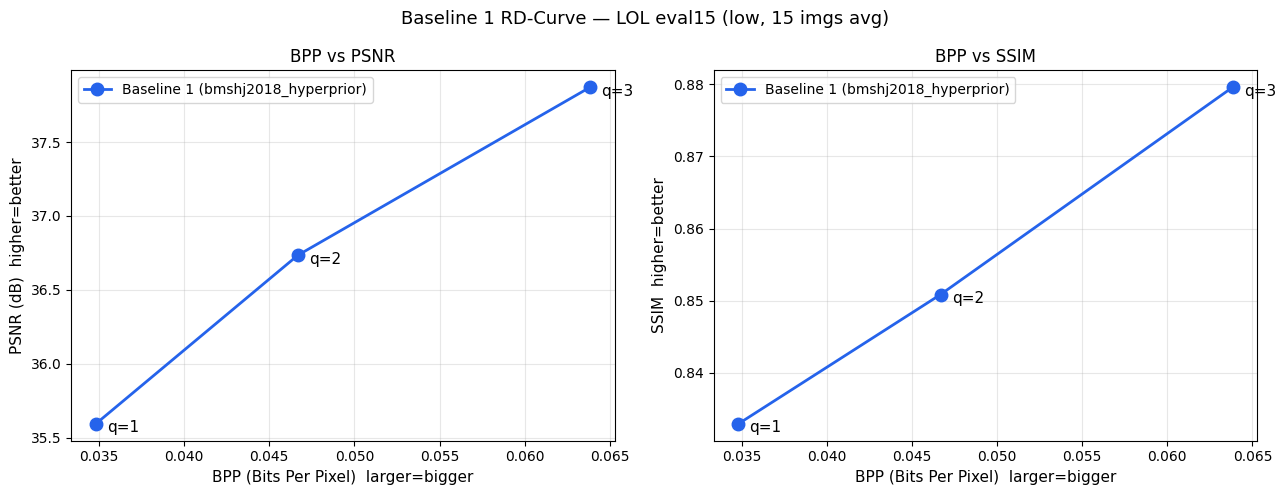

  q |      BPP |  PSNR(dB) |    SSIM
------------------------------------
  1 |   0.0348 |     35.59 |  0.8329
  2 |   0.0467 |     36.73 |  0.8508
  3 |   0.0638 |     37.87 |  0.8796
💾 rd_curve.png 저장 완료


In [4]:
qs = QUALITIES
bpp_pts  = [results[q]['bpp']  for q in qs]
psnr_pts = [results[q]['psnr'] for q in qs]
ssim_pts = [results[q]['ssim'] for q in qs]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, ypts, yl, ttl in [
    (axes[0], psnr_pts, 'PSNR (dB)  higher=better', 'BPP vs PSNR'),
    (axes[1], ssim_pts, 'SSIM  higher=better',      'BPP vs SSIM'),
]:
    ax.plot(bpp_pts, ypts, 'o-', color='#2563eb', lw=2, ms=9,
            label='Baseline 1 (bmshj2018_hyperprior)')
    for q, bx, py in zip(qs, bpp_pts, ypts):
        ax.annotate(f"q={q}", (bx, py), textcoords='offset points', xytext=(8, -6), fontsize=11)
    ax.set_xlabel('BPP (Bits Per Pixel)  larger=bigger', fontsize=11)
    ax.set_ylabel(yl, fontsize=11); ax.set_title(ttl, fontsize=12)
    ax.grid(alpha=0.3); ax.legend()
fig.suptitle(f'Baseline 1 RD-Curve — LOL eval15 ({SPLIT}, {len(paths)} imgs avg)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'rd_curve.png'), dpi=150)
plt.show()

# 표로도 출력
print(f"{'q':>3} | {'BPP':>8} | {'PSNR(dB)':>9} | {'SSIM':>7}")
print('-'*36)
for q in qs:
    r = results[q]
    print(f"{q:>3} | {r['bpp']:>8.4f} | {r['psnr']:>9.2f} | {r['ssim']:>7.4f}")
print("💾 rd_curve.png 저장 완료")

### 5. (확장) 여러 모델 겹쳐 그리기 — 5주차 대조군 비교용
Baseline 2·3·Ours의 학습된 `.pth`를 얹어 **같은 축에 여러 RD 곡선**을 겹치면 대조군 비교표가 된다.

```python
# 예시 스켈레톤
def eval_model(model):
    bpps, psnrs = [], []
    model.eval(); model.update()
    for p in paths:
        x = load_img(p).to(device)
        _,_,H,W = x.shape
        with torch.no_grad():
            out = model.compress(x)
            x_hat = model.decompress(out['strings'], out['shape'])['x_hat'].clamp(0,1)
        bpps.append(sum(len(s[0]) for s in out['strings'])*8/(H*W))
        psnrs.append(psnr(x_hat, x))   # 개선 성능은 psnr(x_hat, high_gt)로 교체
    return np.mean(bpps), np.mean(psnrs)

# ours = bmshj2018_hyperprior(quality=2)
# ours.load_state_dict(torch.load('.../Baseline2.pth')); ours.to(device)
# bpp_o, psnr_o = eval_model(ours)
# plt.plot(bpp_o, psnr_o, 's--', label='Ours')  # Baseline 곡선 위에 겹치기
```

**주의:** 학습 모델은 quality마다 따로 학습해야 곡선(여러 점)이 된다. 한 quality만 학습했다면 그 모델은 **점 1개**로 찍고 Baseline 곡선과 위치를 비교하면 된다.